In [1]:
import xarray as xr
import matplotlib.pyplot as plt

# ds = xr.open_zarr('/nobackup/users/haar/datasets/rain-gauge-adjusted-radar-data.zarr')
ds = xr.open_zarr('/nobackup/users/haar/datasets/MFBS-NL25.zarr')
print(ds)  # see what's in there

<xarray.Dataset> Size: 94GB
Dimensions:     (variable: 9, cell: 535500, time: 4868, ensemble: 1)
Dimensions without coordinates: variable, cell, time, ensemble
Data variables:
    minimum     (variable) float64 72B ...
    mean        (variable) float64 72B ...
    longitudes  (cell) float64 4MB ...
    maximum     (variable) float64 72B ...
    stdev       (variable) float64 72B ...
    latitudes   (cell) float64 4MB ...
    dates       (time) datetime64[s] 39kB ...
    data        (time, variable, ensemble, cell) float32 94GB ...
Attributes: (12/31)
    allow_nans:              False
    attribution:             unknown
    chunks:                  [1, 9, 1, 535500]
    constant_fields:         ['cos_latitude', 'cos_longitude', 'sin_latitude'...
    data_request:            {'area': None, 'grid': None, 'param_level': {}, ...
    description:             No description provided.
    ...                      ...
    total_number_of_files:   4907
    total_size:              25107157318

/tmp/ipykernel_931061/914185491.py:5: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_zarr('/nobackup/users/haar/datasets/MFBS-NL25.zarr')


In [5]:
data = ds['data'][:,8,:,:].squeeze()
# data = ds['data'].squeeze()

In [3]:
mean_precip = data.mean(dim='time').compute()
mean_2d = mean_precip.values.reshape(765, 700)

In [4]:
import numpy as np

lats = ds['latitudes'].compute().values
lons = ds['longitudes'].compute().values
lons = np.nan_to_num(lons, nan=0.0)

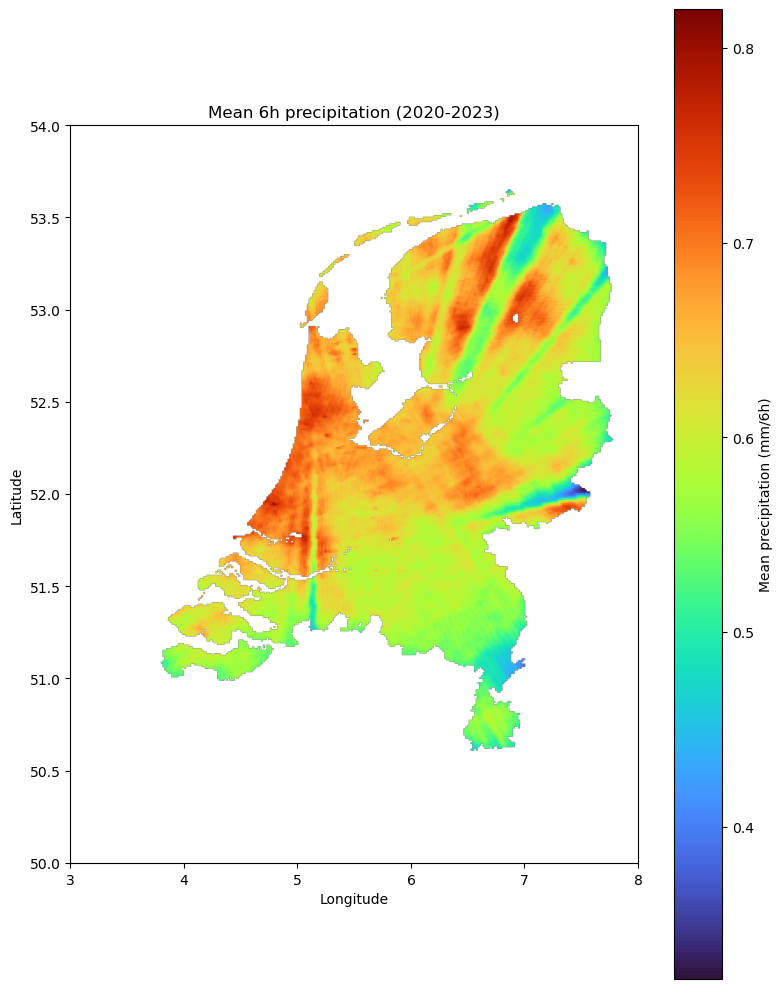

In [6]:
fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(
    mean_2d,
    cmap='turbo',
    origin='upper',
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    aspect=1 / np.cos(np.radians(52))
)
ax.set_xlim(3, 8)
ax.set_ylim(50, 54)
plt.colorbar(im, ax=ax, label='Mean precipitation (mm/6h)')
ax.set_title('Mean 6h precipitation (2020-2023)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('images/mean_precipitation_heatmap_filtered.png', dpi=150)
plt.show()


In [7]:
max_precip = data.max(dim='time').compute().values

max_2d = max_precip.reshape(765, 700)

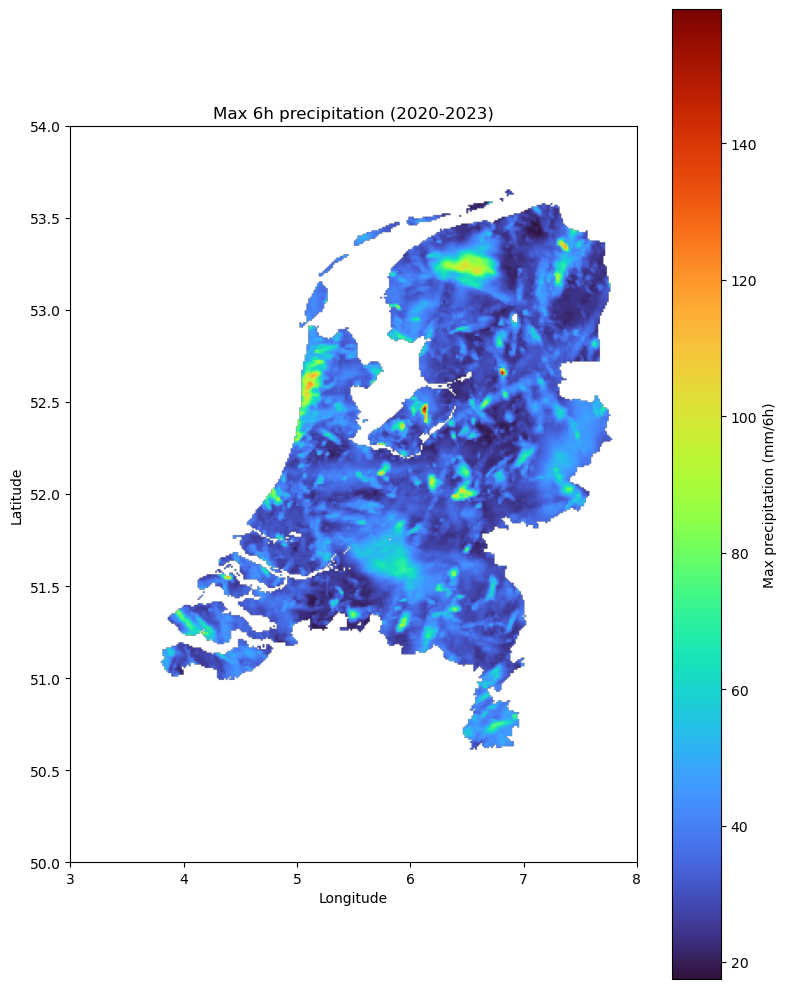

In [8]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(
    max_2d,
    cmap='turbo',
    origin='upper',
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    aspect=1 / np.cos(np.radians(52))
)
ax.set_xlim(3, 8)
ax.set_ylim(50, 54)
plt.colorbar(im, ax=ax, label='Max precipitation (mm/6h)')
ax.set_title('Max 6h precipitation (2020-2023)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('images/max_precip_heatmap_filtered.png', dpi=150)
plt.show()

In [9]:
total = data.shape[0] * data.shape[1]

thresholds = [10, 25, 50, 75, 100, 125, 150, 175]

print(f"Total data points: {total:,}")
print(f"{'Threshold (mm/6h)':<20} {'Count':>12} {'Ratio (%)':>12}")
print("-" * 46)

for t in thresholds:
    count = (data > t).sum().compute()
    ratio = count / total * 100
    print(f"{t:<20} {int(count):>12,} {float(ratio):>12.4f}%")

Total data points: 3,129,462,000
Threshold (mm/6h)           Count    Ratio (%)
----------------------------------------------
10                      2,110,431       0.0674%
25                        100,331       0.0032%
50                          4,705       0.0002%
75                            680       0.0000%
100                           101       0.0000%
125                            10       0.0000%
150                             2       0.0000%
175                             0       0.0000%


Old data:

Total data points: 3,129,462,000
Threshold (mm/6h)           Count    Ratio (%)
----------------------------------------------
10                      2,115,391       0.0676%
25                        100,580       0.0032%
50                          4,752       0.0002%
75                            694       0.0000%
100                           108       0.0000%
125                            13       0.0000%
150                             3       0.0000%
175                             1       0.0000%

In [5]:
import pandas as pd

time_index = pd.date_range(start="2020-01-01", periods=data.sizes["time"], freq="6h")
data = data.assign_coords(time=time_index)

In [15]:
# Daily totals (00:00 to 00:00), then max over time for each spatial point
daily = data.resample(time="1D").sum(min_count=4)
max_daily = daily.max(dim="time")
max_daily_2d = max_daily.values.reshape(765, 700)

In [12]:
def plot_max_data(data, interval_name):
    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.imshow(
        data,
        cmap='turbo',
        origin='upper',
        extent=[lons.min(), lons.max(), lats.min(), lats.max()],
        aspect=1 / np.cos(np.radians(52))
    )
    ax.set_xlim(3, 8)
    ax.set_ylim(50, 54)
    plt.colorbar(im, ax=ax, label=f"Max {interval_name} precipitation")
    ax.set_title(f"Max {interval_name} precipitation (2020-2023)")
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.savefig(f"images/max_{interval_name}_heatmap.png", dpi=150)
    plt.show()

In [ ]:
plot_max_data(max_daily_2d, 'daily')

In [6]:
# Yearly totals, then max over time for each spatial point
yearly = data.resample(time="1YS").sum(min_count=365)  # YS = year start (Jan 1)
max_yearly = yearly.max(dim="time")
max_yearly_2d = max_yearly.values.reshape(765, 700)

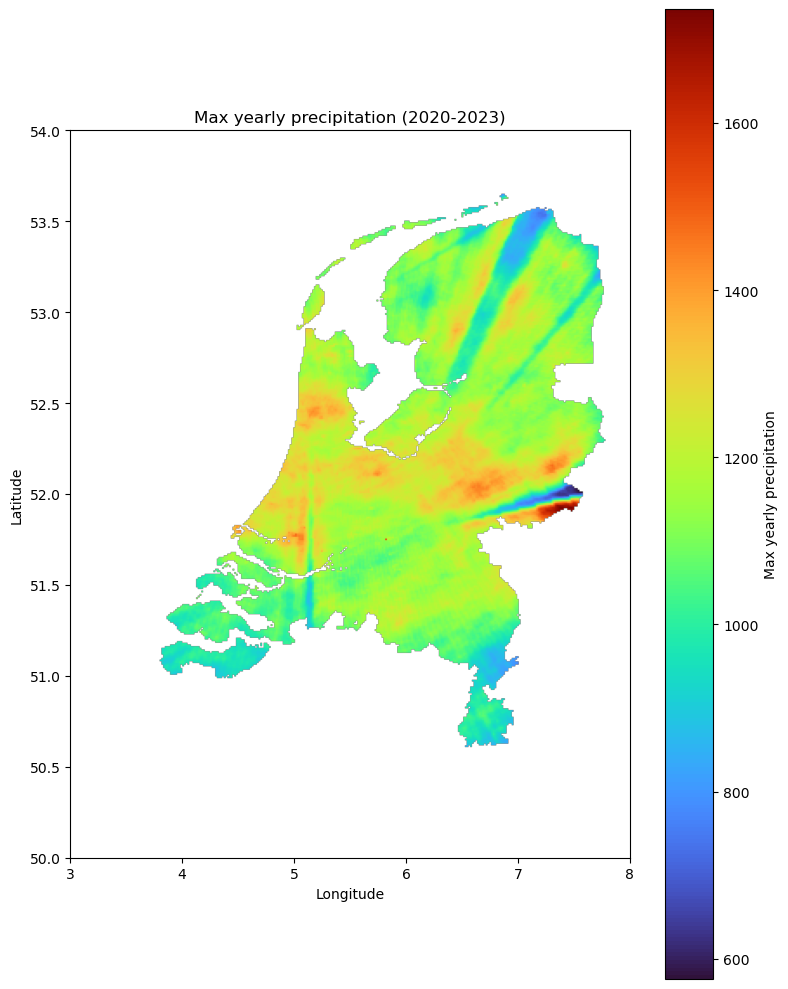

In [14]:
plot_max_data(max_yearly_2d, 'yearly')

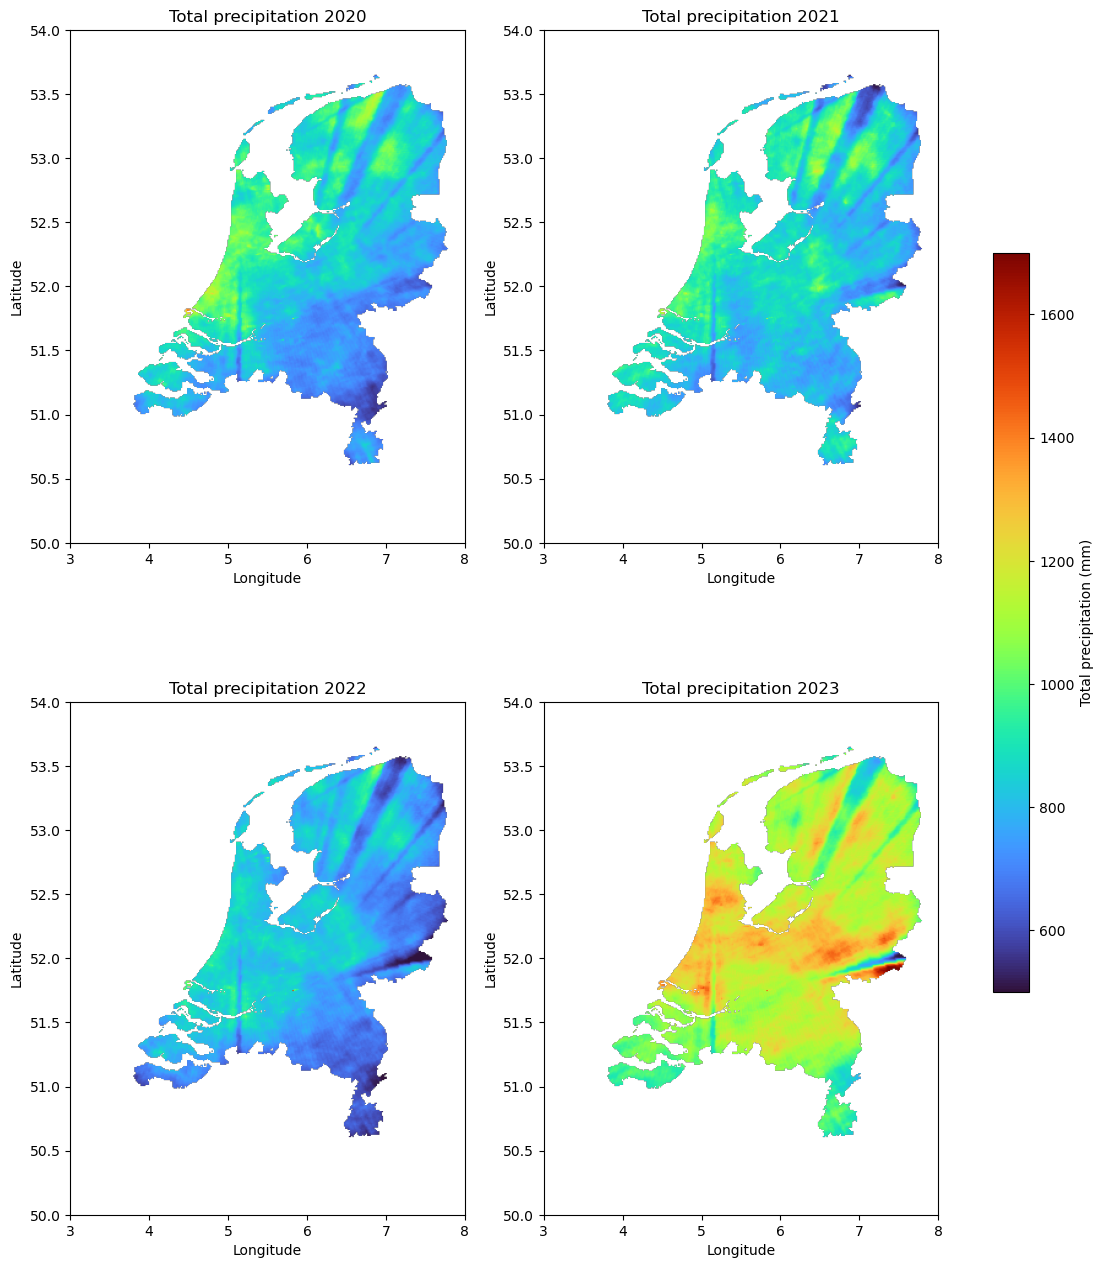

In [18]:
years = [2020, 2021, 2022, 2023]

vmin = 500
vmax = 1700

fig, axes = plt.subplots(2, 2, figsize=(14, 16))

for ax, year, da in zip(axes.flat, years, yearly):
    data_2d = da.values.reshape(765, 700)
    im = ax.imshow(
        data_2d,
        cmap='turbo',
        origin='upper',
        extent=[lons.min(), lons.max(), lats.min(), lats.max()],
        aspect=1 / np.cos(np.radians(52)),
        vmin=vmin, vmax=vmax
    )
    ax.set_xlim(3, 8)
    ax.set_ylim(50, 54)
    ax.set_title(f"Total precipitation {year}")
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

fig.colorbar(im, ax=axes, label="Total precipitation (mm)", shrink=0.6)
plt.savefig("yearly_precipitation_heatmaps.png", dpi=150)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 0 = does not exceed, 1 = exceeds, NaN = NaN
def make_category(mask, source):
    cat = np.where(np.isnan(source), np.nan,
                   np.where(mask, 1.0, 0.0))
    return cat

sixhourly_limit = 80
yearly_limit = 1400
mask_sixhourly  = max_2d  > sixhourly_limit
mask_yearly = max_yearly_2d > yearly_limit
mask_both   = mask_sixhourly & mask_yearly
print(mask_sixhourly.sum())
print(mask_yearly.sum())
print(mask_both.sum())

cat_sixhourly  = make_category(mask_sixhourly,  max_2d)
cat_yearly = make_category(mask_yearly, max_yearly_2d)

# 0 = neither, 1 = 6h only, 2 = yearly only, 3 = both
cat_overlap = np.full(max_2d.shape, np.nan)
valid = ~np.isnan(max_2d) & ~np.isnan(max_yearly_2d)
cat_overlap[valid] = (mask_sixhourly[valid].astype(int) +
                      mask_yearly[valid].astype(int) * 2)

cmap_overlap = mcolors.ListedColormap(["steelblue", "tomato", "orange", "darkred"])

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

kwargs = dict(origin="upper",
              extent=[lons.min(), lons.max(), lats.min(), lats.max()],
              aspect=1 / np.cos(np.radians(52)))

# 6h heatmap
im0 = axes[0].imshow(max_2d, cmap='turbo', **kwargs)
plt.colorbar(im0, ax=axes[0], label='Max precipitation (mm/6h)')
axes[0].set_title('Max 6h precipitation (2020-2023)')

# Yearly heatmap
im1 = axes[1].imshow(max_yearly_2d, cmap='turbo', **kwargs)
plt.colorbar(im1, ax=axes[1], label='Max yearly precipitation (mm)')
axes[1].set_title('Max yearly precipitation (2020-2023)')

# Overlap
im2 = axes[2].imshow(cat_overlap, cmap=cmap_overlap, vmin=0, vmax=3, **kwargs)
cbar2 = plt.colorbar(im2, ax=axes[2], ticks=[0.375, 1.125, 1.875, 2.625])
cbar2.ax.set_yticklabels(["Neither", f"6h >{sixhourly_limit}" , f"Year total > {yearly_limit}", "Both"])
axes[2].set_title("Exceeding thresholds")

for ax in axes:
    ax.set_xlim(3, 8)
    ax.set_ylim(50, 54)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(f"images/threshold_maps_{sixhourly_limit}_{yearly_limit}.png", dpi=150)
plt.show()

NameError: name 'max_2d' is not defined

1309
156
27


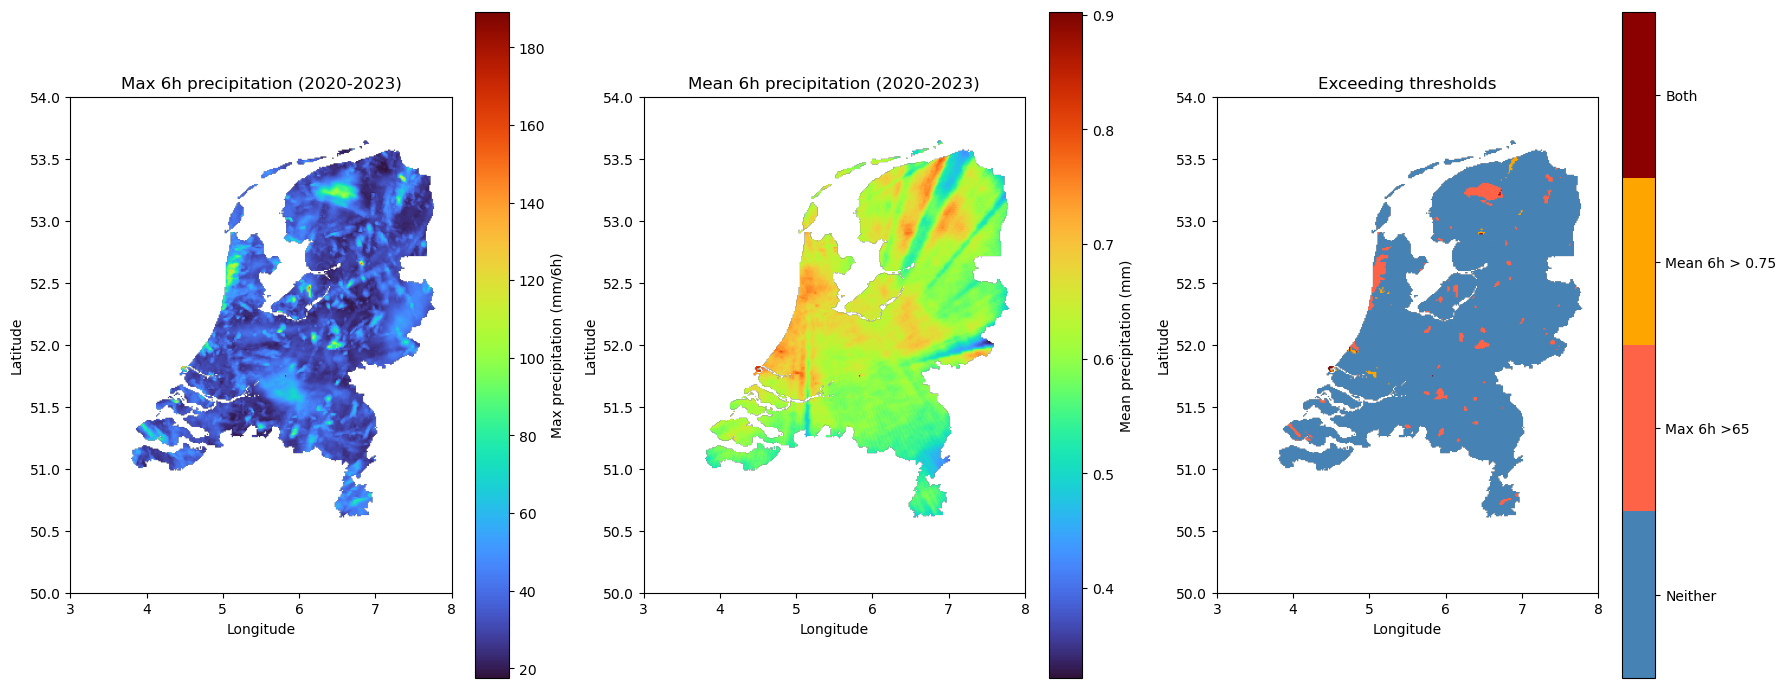

In [28]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 0 = does not exceed, 1 = exceeds, NaN = NaN
def make_category(mask, source):
    cat = np.where(np.isnan(source), np.nan,
                   np.where(mask, 1.0, 0.0))
    return cat

max_limit = 65
mean_limit = 0.75
mask_max  = max_2d  > max_limit
mask_mean = mean_2d > mean_limit
mask_both   = mask_max & mask_mean
print(mask_max.sum())
print(mask_mean.sum())
print(mask_both.sum())

cat_max  = make_category(mask_max,  max_2d)
cat_mean = make_category(mask_mean, mean_2d)

# 0 = neither, 1 = 6h only, 2 = mean only, 3 = both
cat_overlap = np.full(max_2d.shape, np.nan)
valid = ~np.isnan(max_2d) & ~np.isnan(mean_2d)
cat_overlap[valid] = (mask_max[valid].astype(int) +
                      mask_mean[valid].astype(int) * 2)

cmap_overlap = mcolors.ListedColormap(["steelblue", "tomato", "orange", "darkred"])

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

kwargs = dict(origin="upper",
              extent=[lons.min(), lons.max(), lats.min(), lats.max()],
              aspect=1 / np.cos(np.radians(52)))

# 6h heatmap
im0 = axes[0].imshow(max_2d, cmap='turbo', **kwargs)
plt.colorbar(im0, ax=axes[0], label='Max precipitation (mm/6h)')
axes[0].set_title('Max 6h precipitation (2020-2023)')

# Mean heatmap
im1 = axes[1].imshow(mean_2d, cmap='turbo', **kwargs)
plt.colorbar(im1, ax=axes[1], label='Mean precipitation (mm)')
axes[1].set_title('Mean 6h precipitation (2020-2023)')

# Overlap
im2 = axes[2].imshow(cat_overlap, cmap=cmap_overlap, vmin=0, vmax=3, **kwargs)
cbar2 = plt.colorbar(im2, ax=axes[2], ticks=[0.375, 1.125, 1.875, 2.625])
cbar2.ax.set_yticklabels(["Neither", f"Max 6h >{max_limit}" , f"Mean 6h > {mean_limit}", "Both"])
axes[2].set_title("Exceeding thresholds")

for ax in axes:
    ax.set_xlim(3, 8)
    ax.set_ylim(50, 54)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(f"images/max_mean_threshold_maps_{max_limit}_{mean_limit}.png", dpi=150)
plt.show()

In [16]:
daily_vals = daily.values  # shape (time, space) or (time, y, x)

max_day_val = np.nanmax(daily_vals, axis=0)
max_day_idx = np.full(max_day_val.shape, -1, dtype=int)

valid_mask = ~np.isnan(max_day_val)
max_day_idx[valid_mask] = np.nanargmax(daily_vals[:, valid_mask], axis=0)

dates = np.empty(max_day_val.flatten().shape, dtype="datetime64[ns]")
idx_flat   = max_day_idx.flatten()
valid_flat = valid_mask.flatten()

dates[valid_flat]  = daily.time.values[idx_flat[valid_flat]]
dates[~valid_flat] = np.datetime64("NaT")

import pandas as pd

df = pd.DataFrame({
    "date":         dates,
    "lon":          lons.flatten(),
    "lat":          lats.flatten(),
    "max_daily_mm": max_day_val.flatten(),
})

df = df.dropna(subset=["max_daily_mm"])
df = df.sort_values("max_daily_mm", ascending=False).head(100).reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"]).dt.date

print(df.to_string())

          date       lon        lat  max_daily_mm
0   2022-08-02  5.224620  51.850608    189.179993
1   2020-08-14  5.605691  52.495196    181.580002
2   2020-08-14  5.604309  52.486601    164.780014
3   2020-08-14  5.607073  52.503792    157.900009
4   2021-06-03  6.257032  52.636392    154.750000
5   2020-08-14  5.602927  52.478005    153.889999
6   2020-08-14  5.529361  52.551811    153.290009
7   2020-08-14  5.590228  52.487443    149.709991
8   2020-08-14  5.543468  52.550978    148.679993
9   2020-08-14  5.621160  52.502947    146.940002
10  2020-08-14  5.591607  52.496039    146.529999
11  2020-08-14  5.515252  52.552643    144.369995
12  2020-08-14  5.588851  52.478847    142.319992
13  2021-06-03  6.255483  52.627800    139.560013
14  2021-06-18  4.692175  52.675488    138.610001
15  2020-08-14  5.619774  52.494351    138.309998
16  2021-06-18  4.705184  52.666163    138.020004
17  2021-06-18  4.706351  52.674779    137.619980
18  2021-06-18  4.691012  52.666871    136.270004


In [33]:
sixhourly_vals = data.values  # shape (time, y, x) - your 6h dataset

# Flatten spatial dims to (time, space)
sixhourly_flat = sixhourly_vals.reshape(sixhourly_vals.shape[0], -1)

# Only consider pixels where cat_overlap == 3 (both)
overlap_mask = mask_both.flatten()

# Max and argmax over time, NaN-safe
max_6h_val = np.nanmax(sixhourly_flat, axis=0)       # shape (space,)
valid_mask = ~np.isnan(max_6h_val) & overlap_mask

max_6h_idx = np.full(max_6h_val.shape, -1, dtype=int)
max_6h_idx[valid_mask] = np.nanargmax(sixhourly_flat[:, valid_mask], axis=0)

# Map argmax indices to timestamps
dates_6h = np.empty(max_6h_val.shape, dtype="datetime64[ns]")
dates_6h[valid_mask]  = data.time.values[max_6h_idx[valid_mask]]
dates_6h[~valid_mask] = np.datetime64("NaT")

df_6h = pd.DataFrame({
    "date":      dates_6h,
    "lon":       lons.flatten(),
    "lat":       lats.flatten(),
    "max_6h_mm": max_6h_val.flatten(),
})

df_6h = df_6h[valid_mask]  # keeps only mask_both & non-NaN pixels
df_6h = df_6h.sort_values("max_6h_mm", ascending=False).head(100).reset_index(drop=True)
df_6h["date"] = pd.to_datetime(df_6h["date"]).dt.date
print(df_6h.to_string())


          date       lon        lat   max_6h_mm
0   2022-08-02  5.224620  51.850608  189.179993
1   2020-08-03  4.040411  51.979045  133.559998
2   2020-08-03  4.026500  51.979650  128.499985
3   2020-08-03  4.039429  51.970455  120.949997
4   2020-08-03  4.054321  51.978437  111.349998
5   2020-08-03  4.025521  51.971060  110.969994
6   2021-08-05  4.065265  51.952060   93.180008
7   2020-08-03  4.011614  51.971664   88.379997
8   2020-08-03  4.068230  51.977827   84.589996
9   2021-07-25  6.236649  53.160262   83.839996
10  2021-07-25  6.250988  53.159319   82.770004
11  2021-07-25  6.252559  53.167938   78.689995
12  2023-09-11  4.023565  51.953882   76.259995
13  2020-08-17  4.280603  52.115110   75.419998
14  2020-08-17  4.279558  52.106516   74.689995
15  2021-07-25  6.254131  53.176556   72.919998
16  2020-08-03  4.053335  51.969847   72.629997
17  2023-09-11  4.010639  51.963074   72.510002
18  2023-09-11  4.036484  51.944688   72.379997
19  2020-08-17  4.278514  52.097922   69

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

years = [2020, 2021, 2022, 2023]

# ── 1. Per-year stats (valid pixels only) ────────────────────────────────────
stats = {}
yearly_2d = []
for year, da in zip(years, yearly):
    data = da.values.reshape(765, 700)
    yearly_2d.append(data)
    valid = data[~np.isnan(data)]
    mu, sigma = valid.mean(), valid.std()
    stats[year] = dict(mean=mu, std=sigma)
    print(f"{year}  mean={mu:.1f} mm  std={sigma:.1f} mm")

# ── 2. Category boundaries & palette ─────────────────────────────────────────
# 7 bins:  <μ-3σ | μ-3σ…μ-2σ | μ-2σ…μ-σ | μ-σ…μ+σ | μ+σ…μ+2σ | μ+2σ…μ+3σ | >μ+3σ
COLORS = ["#053061", "#4393c3", "#92c5de", "#f7f7f7", "#f4a582", "#d6604d", "#67001f"]
LABELS = ["< μ−3σ", "μ−3σ … μ−2σ", "μ−2σ … μ−σ", "μ−σ … μ+σ",
          "μ+σ … μ+2σ", "μ+2σ … μ+3σ", "> μ+3σ"]
cmap_cat = mcolors.ListedColormap(COLORS)

def categorise(data, mu, sigma):
    """Return integer category 0-6; NaN pixels stay NaN."""
    edges = [mu + k * sigma for k in (-3, -2, -1, 1, 2, 3)]
    cat = np.full(data.shape, np.nan)
    valid = ~np.isnan(data)
    v = data[valid]
    c = np.full(v.shape, 6, dtype=float)          # default: top bin
    for bin_idx, threshold in enumerate(edges):
        c[v <= threshold] = bin_idx               # fill from the left
        # once a pixel is assigned it won't be overwritten because we
        # assign in ascending order and only shrink the pool implicitly
    # build properly: use np.digitize-style logic
    c = np.zeros(v.shape, dtype=float)
    c[v <= edges[0]] = 0
    c[(v > edges[0]) & (v <= edges[1])] = 1
    c[(v > edges[1]) & (v <= edges[2])] = 2
    c[(v > edges[2]) & (v <= edges[3])] = 3
    c[(v > edges[3]) & (v <= edges[4])] = 4
    c[(v > edges[4]) & (v <= edges[5])] = 5
    c[v > edges[5]] = 6
    cat[valid] = c
    return cat

# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
kwargs = dict(origin="upper",
              extent=[lons.min(), lons.max(), lats.min(), lats.max()],
              aspect=1 / np.cos(np.radians(52)),
              cmap=cmap_cat, vmin=-0.5, vmax=6.5)

for ax, year, data in zip(axes.flat, years, yearly_2d):
    mu    = stats[year]["mean"]
    sigma = stats[year]["std"]
    cat   = categorise(data, mu, sigma)

    ax.imshow(cat, **kwargs)
    ax.set_xlim(3, 8)
    ax.set_ylim(50, 54)
    ax.set_title(f"Precipitation categories {year}\n(μ={mu:.0f} mm, σ={sigma:.0f} mm)",
                 fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

# Shared legend
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
fig.legend(handles=patches, title="Deviation from yearly mean",
           loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("yearly_precipitation_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from scipy.stats import genextreme
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

# ── 1. Fit GEV to max_2d ─────────────────────────────────────────────────────
valid_6h = max_2d[~np.isnan(max_2d)].flatten()

# genextreme uses the convention shape = -ξ, so we negate it back when reporting

sixhourly_limit = np.nanpercentile(max_2d, 99.9)
print(f"99.9th percentile threshold: {sixhourly_limit:.1f} mm")


# ── 5. Rebuild masks with GEV threshold ──────────────────────────────────────
mask_sixhourly = max_2d > sixhourly_limit

mask_yearly = np.zeros(max_2d.shape, dtype=bool)
for year, data in zip(years, yearly_2d):
    mu    = stats[year]["mean"]
    sigma = stats[year]["std"]
    mask_yearly |= (data > mu + 3 * sigma)   # yearly totals keep σ-based threshold

mask_both = mask_sixhourly & mask_yearly

print(f"\nmask_sixhourly (GEV): {mask_sixhourly.sum()} pixels")
print(f"mask_yearly:          {mask_yearly.sum()} pixels")
print(f"mask_both:            {mask_both.sum()} pixels")

cat_overlap = np.full(max_2d.shape, np.nan)
valid = ~np.isnan(max_2d)
cat_overlap[valid] = (mask_sixhourly[valid].astype(int) +
                      mask_yearly[valid].astype(int) * 2)

# ── 7. Main 6-panel figure (same layout as before) ───────────────────────────
COLORS = ["#053061", "#4393c3", "#92c5de", "#f7f7f7", "#f4a582", "#d6604d", "#67001f"]
LABELS = ["< μ−3σ", "μ−3σ … μ−2σ", "μ−2σ … μ−σ", "μ−σ … μ+σ",
          "μ+σ … μ+2σ", "μ+2σ … μ+3σ", "> μ+3σ"]
cmap_cat     = mcolors.ListedColormap(COLORS)
cmap_overlap = mcolors.ListedColormap(["steelblue", "tomato", "orange", "darkred"])

from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

ax_2020 = fig.add_subplot(gs[0, 0])
ax_2021 = fig.add_subplot(gs[0, 1])
ax_2022 = fig.add_subplot(gs[1, 0])
ax_2023 = fig.add_subplot(gs[1, 1])
ax_6h   = fig.add_subplot(gs[0, 2])
ax_over = fig.add_subplot(gs[1, 2])

kwargs_base = dict(origin="upper",
                   extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                   aspect=1 / np.cos(np.radians(52)))

for ax, year, data in zip([ax_2020, ax_2021, ax_2022, ax_2023], years, yearly_2d):
    mu    = stats[year]["mean"]
    sigma = stats[year]["std"]
    cat   = categorise(data, mu, sigma)
    ax.imshow(cat, cmap=cmap_cat, vmin=-0.5, vmax=6.5, **kwargs_base)
    ax.set_title(f"Precipitation categories {year}\n(μ={mu:.0f} mm, σ={sigma:.0f} mm)", fontsize=10)

im0 = ax_6h.imshow(max_2d, cmap='turbo', **kwargs_base)
plt.colorbar(im0, ax=ax_6h, label='Max precipitation (mm/6h)')
ax_6h.set_title(f'Max 6h precipitation (2020–2023)')

im1 = ax_over.imshow(cat_overlap, cmap=cmap_overlap, vmin=0, vmax=3, **kwargs_base)
cbar1 = plt.colorbar(im1, ax=ax_over, ticks=[0.375, 1.125, 1.875, 2.625])
cbar1.ax.set_yticklabels([
    "Neither",
    f"6h > {sixhourly_limit:.0f} mm",
    "Yearly > μ+3σ\n(any year)",
    "Both"
])
ax_over.set_title("Exceeding thresholds")

for ax in [ax_2020, ax_2021, ax_2022, ax_2023, ax_6h, ax_over]:
    ax.set_xlim(3, 8)
    ax.set_ylim(50, 54)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
fig.legend(handles=patches, title="Deviation from yearly mean",
           loc="lower center", ncol=7, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))

plt.savefig("images/threshold_and_categorical_maps_gev.png", dpi=150, bbox_inches="tight")
plt.show()

In [2]:
import pandas as pd
import numpy as np

# ── 1. Load the full coordinate lookup table ──────────────────────────────────
rows = []
with open("radarcoordinaten_NL25_1km2_lon_lat_RD.txt") as f:
    for line in f:
        if line.startswith("#") or line.strip() == "":
            continue
        parts = line.split()
        rows.append(dict(
            x    = int(parts[0]),
            y    = int(parts[1]),
            rd_x = float(parts[2]),
            rd_y = float(parts[3]),
            lon  = float(parts[4]),
            lat  = float(parts[5]),
        ))
lookup = pd.DataFrame(rows)


Matched: 78 / 78


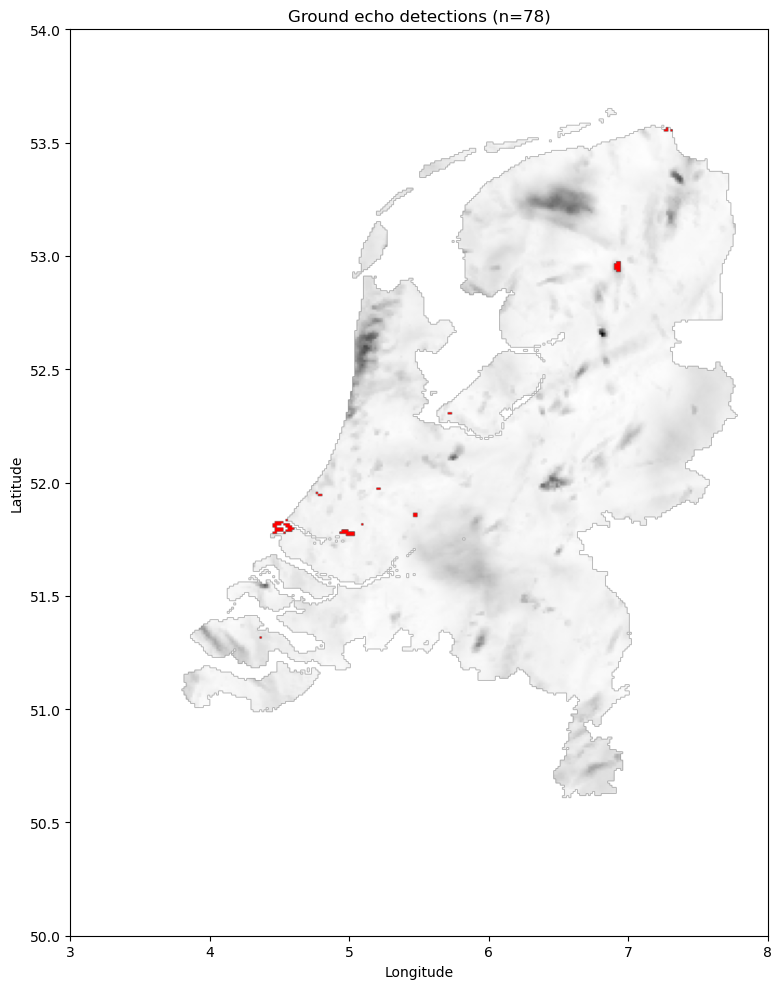

In [8]:
# ── 1. Load ground echo detections as x,y grid indices ───────────────────────
# Match RD coords from .dat against lookup table to get grid x,y
ground_echo_rd = pd.read_csv("GrondEchoDetectieAlledurenDefinitief.dat",
                              sep=r"\s+", header=None, names=["rd_x", "rd_y"])

lookup["rd_x_r"] = lookup["rd_x"].round(3)
lookup["rd_y_r"] = lookup["rd_y"].round(3)
ground_echo_rd["rd_x_r"] = ground_echo_rd["rd_x"].round(3)
ground_echo_rd["rd_y_r"] = ground_echo_rd["rd_y"].round(3)

matched = ground_echo_rd.merge(lookup[["rd_x_r", "rd_y_r", "x", "y"]],
                                on=["rd_x_r", "rd_y_r"], how="left")
print(f"Matched: {matched['x'].notna().sum()} / {len(matched)}")

# ── 2. Build a boolean mask on the 765x700 grid ───────────────────────────────
echo_mask = np.zeros((765, 700), dtype=bool)
valid_matches = matched.dropna(subset=["x", "y"])
echo_mask[valid_matches["x"].astype(int), valid_matches["y"].astype(int)] = True

# ── 3. Build an RGBA overlay: red where echo, transparent elsewhere ───────────
overlay = np.zeros((765, 700, 4), dtype=float)
overlay[echo_mask] = [1, 0, 0, 1]      # solid red
overlay[~echo_mask] = [0, 0, 0, 0]     # fully transparent

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 10))

kwargs_base = dict(origin="upper",
                   extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                   aspect=1 / np.cos(np.radians(52)))

ax.imshow(max_2d, cmap="Greys", **kwargs_base)
ax.imshow(overlay, **kwargs_base)

ax.set_xlim(3, 8)
ax.set_ylim(50, 54)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Ground echo detections (n={echo_mask.sum()})")

plt.tight_layout()
plt.savefig("images/ground_echo_detections.png", dpi=150)
plt.show()

Cluster  4:   34 px  centroid grid=(450, 291)
Cluster  6:   14 px  centroid grid=(453, 321)
Cluster  0:   13 px  centroid grid=(326, 446)
Cluster  1:    4 px  centroid grid=(444, 352)
Cluster  3:    4 px  centroid grid=(261, 469)
Cluster  5:    3 px  centroid grid=(435, 308)
Cluster  2:    2 px  centroid grid=(396, 368)
Cluster  7:    2 px  centroid grid=(432, 336)
358
439


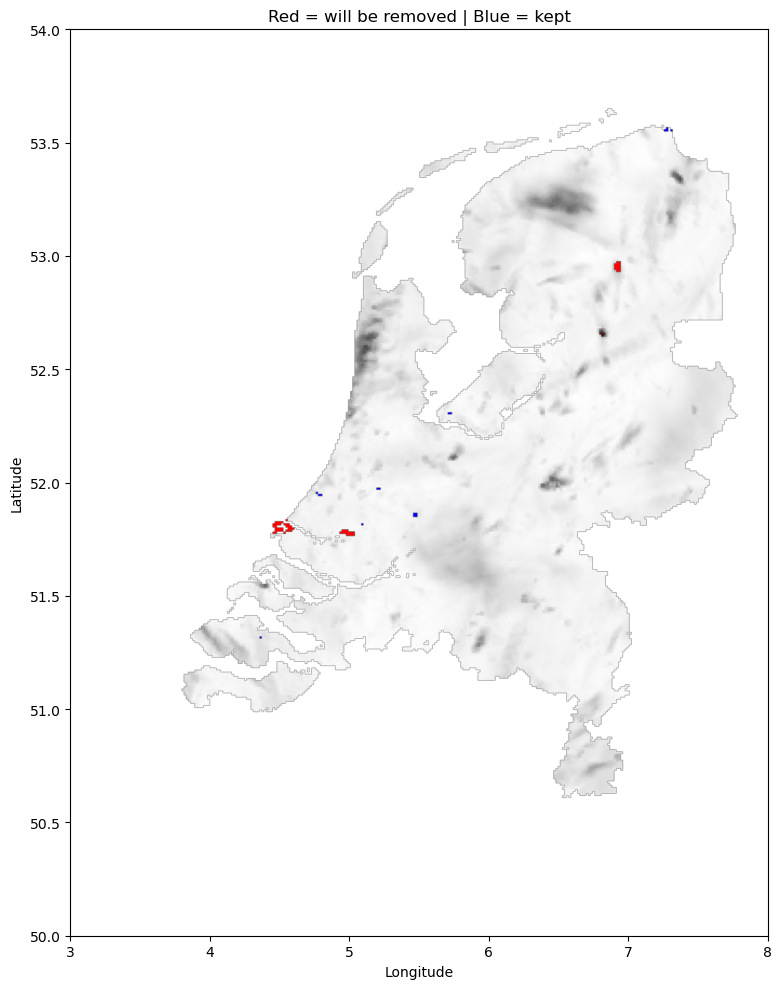

In [9]:
from sklearn.cluster import DBSCAN
import numpy as np

# Grid coords of all red points
xy = valid_matches[["x", "y"]].astype(int).values  # shape (n_red, 2)

# Cluster in grid space — eps=3 means pixels within 3 grid cells join a cluster
db = DBSCAN(eps=3, min_samples=2).fit(xy)
labels = db.labels_

# Inspect cluster sizes to confirm 3 main ones
unique, counts = np.unique(labels[labels >= 0], return_counts=True)
for lbl, cnt in sorted(zip(unique, counts), key=lambda x: -x[1])[:8]:
    centroid = xy[labels == lbl].mean(axis=0)
    print(f"Cluster {lbl:2d}: {cnt:4d} px  centroid grid=({centroid[0]:.0f}, {centroid[1]:.0f})")

# Pick the 3 largest
top3 = unique[np.argsort(counts)[-3:]]
removal_mask = np.isin(labels, top3)

# Build a boolean grid mask of points to remove
remove_grid = np.zeros((765, 700), dtype=bool)
remove_grid[xy[removal_mask, 0], xy[removal_mask, 1]] = True

# Add the problematic windmill park near radar in Herwijnen manually
max_y, max_x = np.unravel_index(np.nanargmax(max_2d), max_2d.shape)
print(max_y)
print(max_x)
remove_grid[max_y, max_x] = True

# Verify visually
overlay2 = np.zeros((765, 700, 4), dtype=float)
overlay2[echo_mask & ~remove_grid] = [0, 0, 1, 1]  # kept echoes: grey
overlay2[remove_grid]              = [1, 0, 0, 1]          # to remove: red

fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(max_2d, cmap="Greys", **kwargs_base)
ax.imshow(overlay2, **kwargs_base)
ax.set_xlim(3, 8)
ax.set_ylim(50, 54)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Red = will be removed | Blue = kept")
plt.tight_layout()
plt.savefig("images/removals.png", dpi=150)
plt.show()


In [10]:
# Flatten the 2D removal mask to 1D indices matching the zarr's 535500 axis
# You need the same flattening order used when building the zarr
# Based on field_shape=[765,700] and flatten_grid=True, it's C-order row-major
flat_remove = np.where(remove_grid.ravel())[0]

keep_idx = np.setdiff1d(np.arange(535500), flat_remove)
print(flat_remove)
np.save('flat_remove.npy', flat_remove)

[227246 227247 227945 227946 227947 228645 228646 228647 229345 229346
 229347 230046 230047 251039 313193 313888 313889 313890 313891 314587
 314588 314589 314590 314592 314593 314594 315287 315288 315293 315294
 315295 315988 315989 315990 315991 315994 315995 315996 316688 316689
 316690 316691 316693 316694 316695 316719 316720 316721 317387 317388
 317392 317418 317419 317420 317421 317422 317423 317424 318121 318122
 318123 318124]


In [7]:
import xarray as xr
import matplotlib.pyplot as plt

ds_filtered = xr.open_zarr('/nobackup/users/haar/datasets/rain-gauge-adjusted-radar-data-filtered.zarr')

data_filtered = ds_filtered['data'][:,8,:,:].squeeze()
mean_precip_filtered = data_filtered.mean(dim='time').compute()
max_precip_filtered = data_filtered.max(dim='time').compute()

/tmp/ipykernel_4123826/721901061.py:4: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds_filtered = xr.open_zarr('/nobackup/users/haar/datasets/rain-gauge-adjusted-radar-data-filtered.zarr')
/usr/people/haar/.local/lib/python3.13/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/usr/people/haar/.local/lib/python3.13/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_c

In [1]:
import numpy as np

flat_remove = np.load('flat_remove.npy')
print(len(flat_remove))

62


In [5]:
import zarr
import numpy as np

ds1 = zarr.open('/nobackup/users/haar/datasets/problematic-points-removed.zarr', mode='r')
ds2 = zarr.open('/nobackup/users/haar/datasets/rain-gauge-adjusted-radar-data.zarr', mode='r')


for ds in [ds1, ds2]:
    # Load one timestep and count NaNs
    t0 = ds['data'][0, 8, 0, :]  # shape (535500,)
    print(f"Total points:  {len(t0)}")
    print(f"NaN points:    {np.isnan(t0).sum()}")
    print(f"Valid points:  {np.isfinite(t0).sum()}")
    print(f"NaN fraction:  {np.isnan(t0).mean():.1%}")

Total points:  535500
NaN points:    497499
Valid points:  38001
NaN fraction:  92.9%
Total points:  535500
NaN points:    497437
Valid points:  38063
NaN fraction:  92.9%


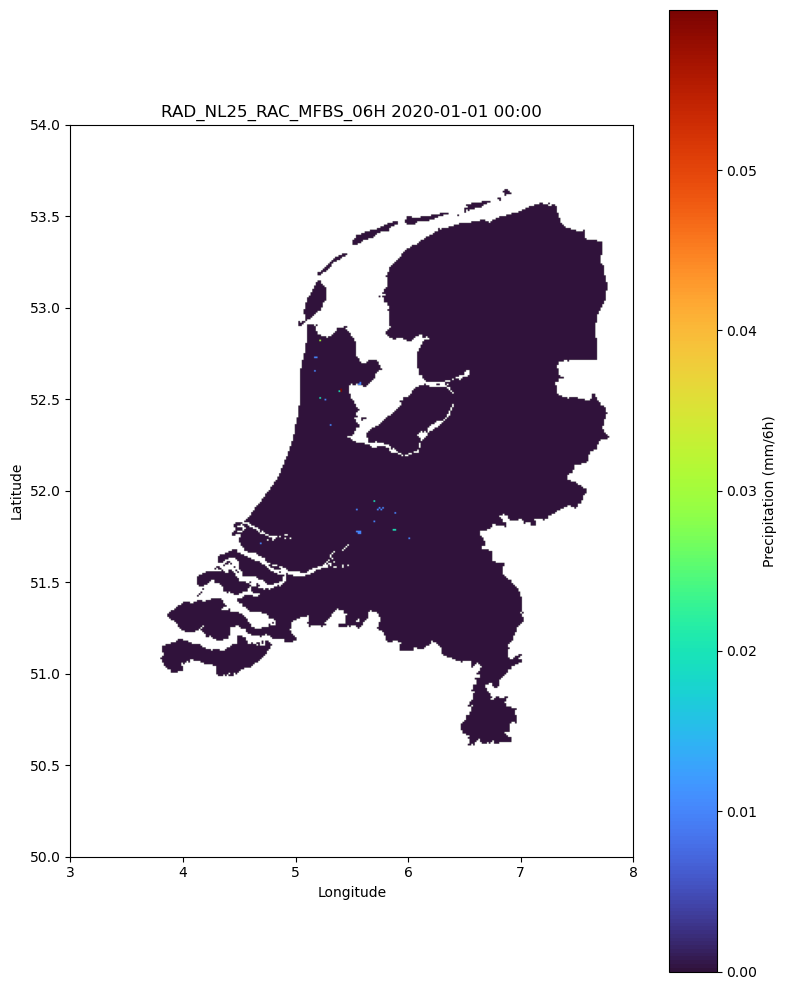

[nan nan nan nan nan nan nan nan nan nan]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


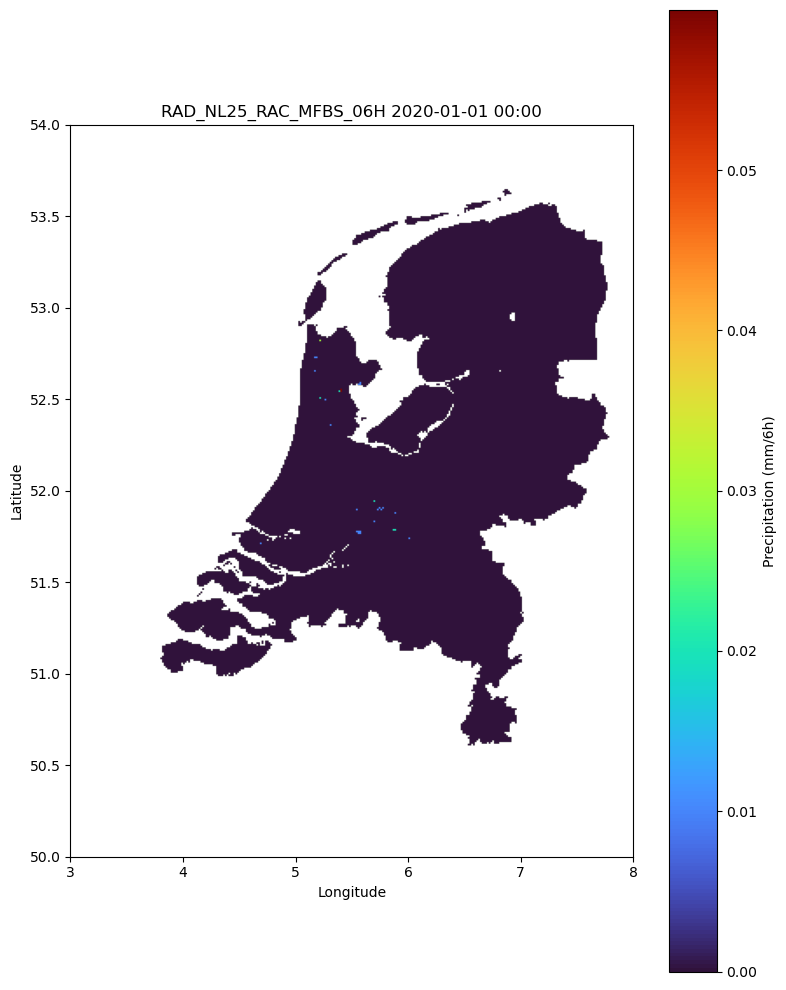

[nan nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan]


In [17]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

path1 = "/nobackup/users/haar/radar_data/MFBS/6H20-23-reprojected/2020/01/RAD_NL25_RAC_MFBS_06H_202001010600.nc"
path2 = "/nobackup/users/haar/radar_data/MFBS/6H20-23-final/2020/01/RAD_NL25_RAC_MFBS_06H_202001010600.nc"

for path in [path1, path2]:
    with nc.Dataset(path, 'r') as ds:
        tp  = ds['tp'][:]          # (765, 700)
        lat = ds['latitude'][:]    # (765, 700)
        lon = ds['longitude'][:]   # (765, 700)

    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.imshow(
        tp,
        cmap='turbo',
        origin='upper',
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
        aspect=1 / np.cos(np.radians(52))
    )
    ax.set_xlim(3, 8)
    ax.set_ylim(50, 54)
    plt.colorbar(im, ax=ax, label='Precipitation (mm/6h)')
    ax.set_title('RAD_NL25_RAC_MFBS_06H 2020-01-01 00:00')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.show()

    print(tp[0][:10].data)
    print(tp.flatten()[flat_remove].data)